# Expansion Analysis

This notebook summarizes the latest materialized synthetic expansion analysis, shows synthetic-only power-flow stress based on compact summary tables, and maps expansion cost envelopes per supplied synthetic grid area.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd


def find_postprocessing_dir() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "plotting").is_dir() and (candidate / "expansion").is_dir():
            return candidate
    raise FileNotFoundError("Could not find GridExpand/5.postprocessing from the notebook working directory.")


POSTPROCESSING_DIR = find_postprocessing_dir()
if str(POSTPROCESSING_DIR) not in sys.path:
    sys.path.insert(0, str(POSTPROCESSING_DIR))

from expansion import grid_expansion
from plotting import geoplotting, powerflow_plotting

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


In [2]:
# Materialized expansion analyses for the TSAM summary run.
PRE_ANALYSIS_KEY = "full_year_all_tsam_pre"
POST_ANALYSIS_KEY = "full_year_all_tsam_post"
ANALYSIS_KEYS = {
    "Pre": PRE_ANALYSIS_KEY,
    "Post-all": POST_ANALYSIS_KEY,
}

# Keep ANALYSIS_KEY as the default single-stage view for the summary tables below.
ANALYSIS_KEY = POST_ANALYSIS_KEY

# Set SYNTHETIC_SUMMARY_RUN_NAME to None to use the latest synthetic compact summary run.
SYNTHETIC_SUMMARY_RUN_NAME = "baseline_static_all_summary_powerflow"
SUMMARY_STAGES = {
    "Pre": "pre",
    "Post-all": "post",
}
SUMMARY_STAGE = SUMMARY_STAGES["Post-all"]
PLZ = None
SCENARIO_ID = None

ASSET_CUTOFF_PERCENTILE = 1.0
OUTPUT_DIR = POSTPROCESSING_DIR / "plotting" / "output" / "expansion"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Load Expansion Analysis

The materialized expansion analysis is loaded once here and reused by the following plots. Summary tables are collected at the bottom of the notebook so the visual analysis comes first.


In [3]:
expansion_tables_by_stage = {
    label: grid_expansion.load_expansion_overview(analysis_key=key)
    for label, key in ANALYSIS_KEYS.items()
}

# Default single-stage tables used by the existing summary cells below.
expansion_tables = expansion_tables_by_stage["Post-all"]
analysis_key = expansion_tables["analysis_key"]
analysis_meta_by_stage = {
    label: tables["analysis_run"].iloc[0]
    for label, tables in expansion_tables_by_stage.items()
}

pd.DataFrame(
    [
        {
            "stage_label": label,
            "analysis_key": tables["analysis_key"],
            "run_name": analysis_meta_by_stage[label]["run_name"],
            "stage": analysis_meta_by_stage[label]["stage"],
            "grids_with_expansion_summary": tables["grid_cost_summary"]["grid_case_id"].nunique() if not tables["grid_cost_summary"].empty else 0,
            "total_cost_eur": float(tables["cost_summary"].iloc[0]["total_cost_eur"]) if not tables["cost_summary"].empty else 0.0,
        }
        for label, tables in expansion_tables_by_stage.items()
    ]
)


,stage_label,analysis_key,run_name,stage,grids_with_expansion_summary,total_cost_eur
0,Pre,full_year_all_tsam_pre,baseline_static_all_summary_powerflow,pre,90,0.000000e+00
1,Post-all,full_year_all_tsam_post,baseline_static_all_summary_powerflow,post,89,5.046409e+06


## Synthetic Power-Flow Stress Overview

This reuses the retained-asset cutoff plot from the power-flow comparison workflow, but shows the synthetic run only. The plot is based on compact summary rows, so it stays lightweight even for many grids.


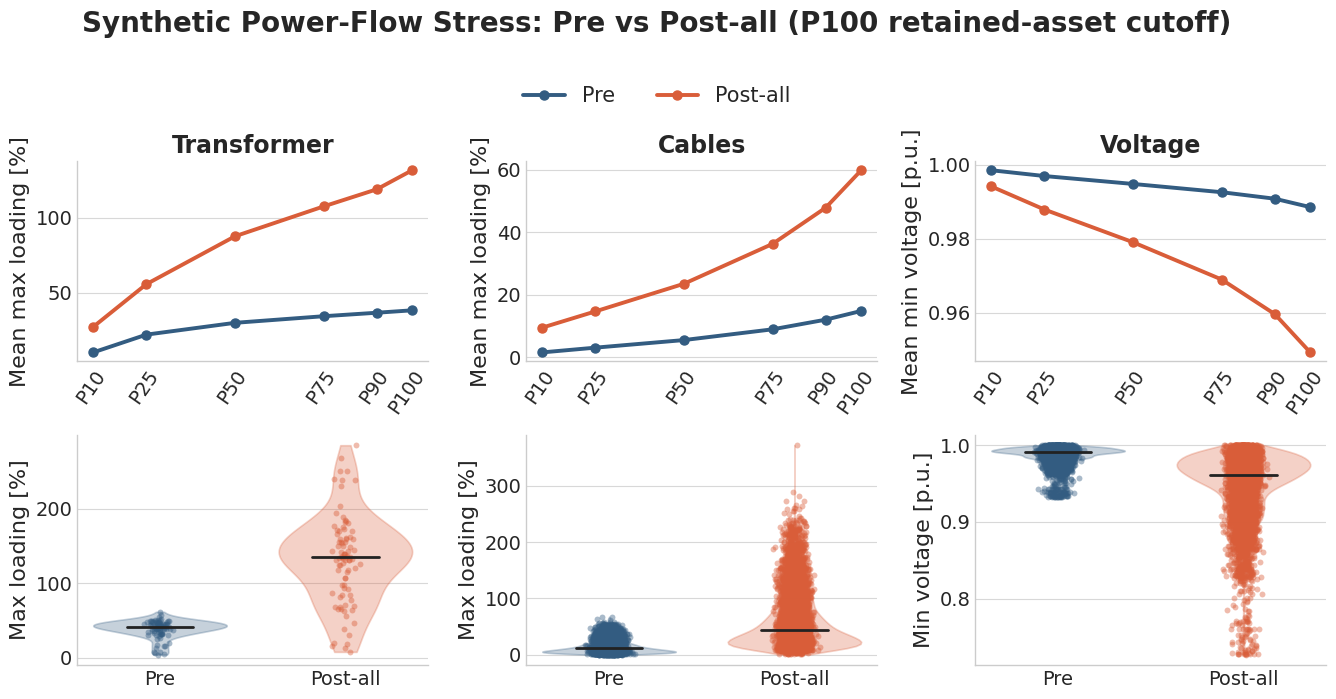

In [4]:
synthetic_summary = pd.DataFrame()
try:
    synthetic_profiles = []
    for label, stage in SUMMARY_STAGES.items():
        profile = powerflow_plotting.load_synthetic_powerflow_cutoff_profile(
            run_name=SYNTHETIC_SUMMARY_RUN_NAME,
            stage=stage,
            scenario_id=SCENARIO_ID,
            plz=PLZ,
        )
        profile["comparison_stage"] = label
        synthetic_profiles.append(profile)

    synthetic_profile = pd.concat(synthetic_profiles, ignore_index=True)
    synthetic_summary = (
        synthetic_profile.groupby(["comparison_stage", "metric", "asset_type"], as_index=False)
        .agg(assets=("asset_id", "count"), grids=("grid", "nunique"))
        .sort_values(["comparison_stage", "metric", "asset_type"])
    )
    fig = powerflow_plotting.plot_powerflow_asset_cutoff_overview_static(
        synthetic_profile,
        group_col="comparison_stage",
        color_map={"Pre": "#335C81", "Post-all": "#D95D39"},
        asset_cutoff_percentile=ASSET_CUTOFF_PERCENTILE,
        asset_percentiles=(0.10, 0.25, 0.50, 0.75, 0.90, 1.0),
        worst_asset_per_grid=False,
        title="Synthetic Power-Flow Stress: Pre vs Post-all",
        save_path=OUTPUT_DIR / "pre_post_asset_cutoff_overview",
    )
    plt.show()
except ValueError as exc:
    print(exc)


## Weekly Power-Flow Diagnostics

These plots reuse the raw full power-flow run behind the materialized expansion analysis. The voltage histogram summarizes grid-level voltage extrema over the analyzed week; the transformer import plot shows the weekly import pattern and load-duration curve across the synthetic grid population.


In [5]:
def _meta_filter(meta: pd.Series) -> dict:
    return {
        "run_name": meta["run_name"],
        "stage": meta["stage"],
        "scenario_id": None if pd.isna(meta["scenario_id"]) else int(meta["scenario_id"]),
        "ags": None if pd.isna(meta["ags"]) else int(meta["ags"]),
        "plz": None if pd.isna(meta["plz"]) else int(meta["plz"]),
    }

voltage_summaries = {}
for label, meta in analysis_meta_by_stage.items():
    meta_filter = _meta_filter(meta)
    voltage_summaries[label] = powerflow_plotting.voltage_deviation_summary_db(
        run_name=meta_filter["run_name"],
        stages=(meta_filter["stage"],),
        scenario_id=meta_filter["scenario_id"],
        ags=meta_filter["ags"],
        plz=meta_filter["plz"],
    )

voltage_fig = powerflow_plotting.plot_voltage_deviation_histogram_comparison(
    voltage_summaries,
    lower_limit=0.95,
    upper_limit=1.03,
    show=False,
)
try:
    powerflow_plotting.save_plotly_figure(
        voltage_fig,
        OUTPUT_DIR / "pre_post_voltage_deviation_histogram",
        formats=("svg", "png"),
        width=980,
        height=440,
    )
except RuntimeError as exc:
    print(f"Could not export voltage histogram: {exc}")
display(voltage_fig)


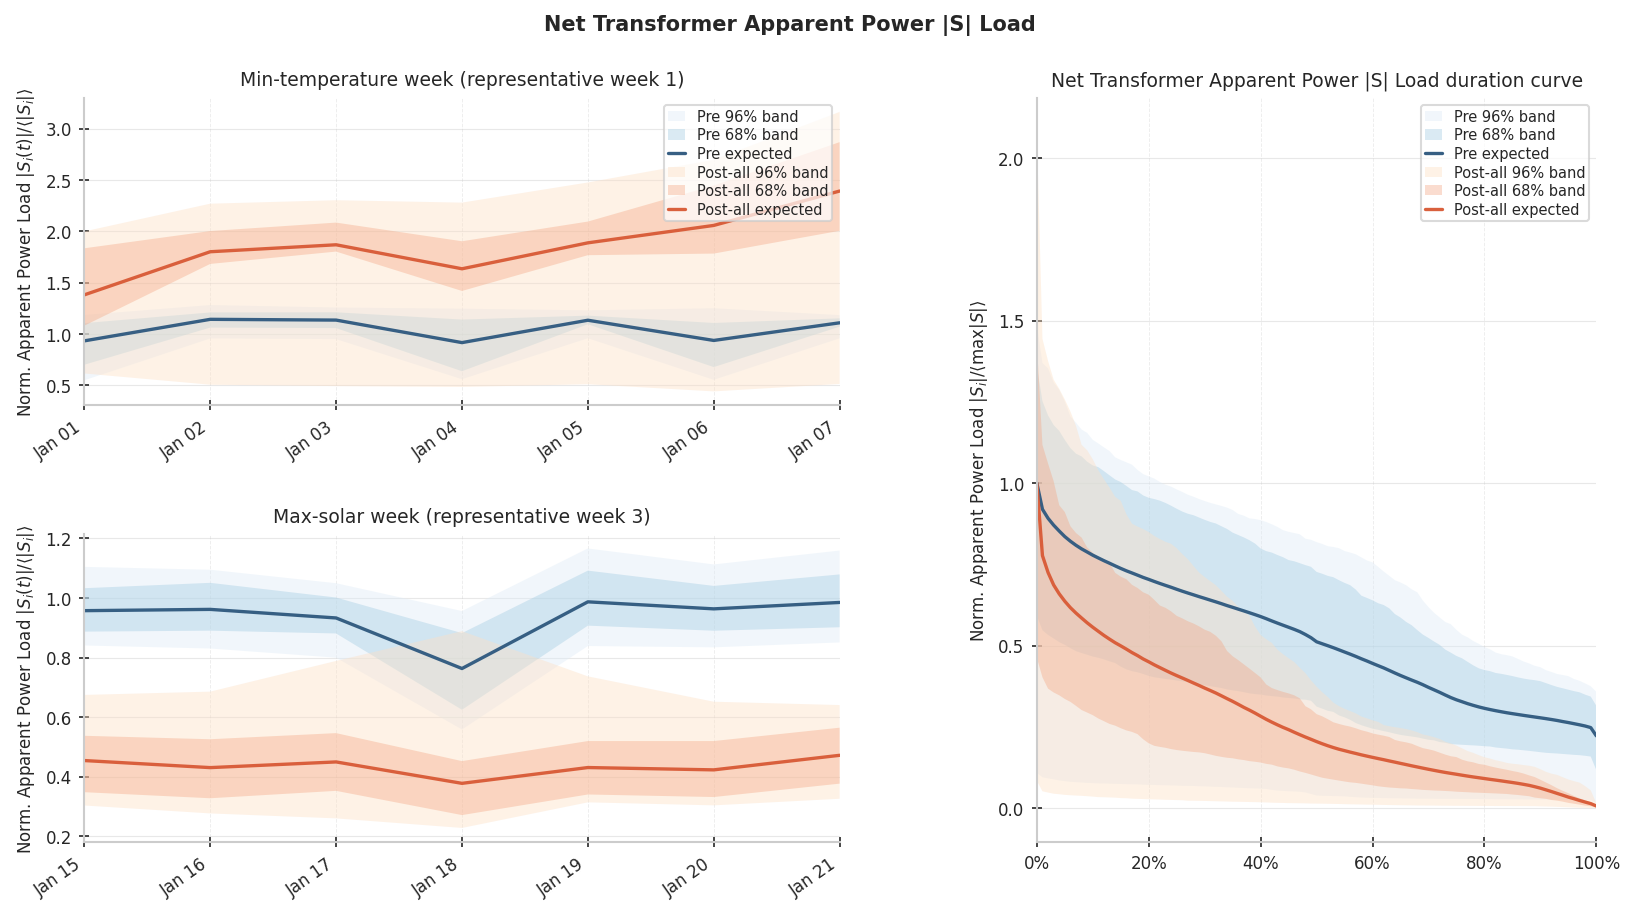

In [6]:
transformer_distributions = []
for label, meta in analysis_meta_by_stage.items():
    meta_filter = _meta_filter(meta)
    distribution = powerflow_plotting.transformer_import_distribution_db(
        run_name=meta_filter["run_name"],
        stage=meta_filter["stage"],
        scenario_id=meta_filter["scenario_id"],
        ags=meta_filter["ags"],
        plz=meta_filter["plz"],
    )
    distribution["comparison_stage"] = label
    transformer_distributions.append(distribution)

transformer_distribution = pd.concat(transformer_distributions, ignore_index=True)
transformer_fig = powerflow_plotting.plot_transformer_import_distributions_matplotlib(
    transformer_distribution,
    metrics=("s",),
    group_col="comparison_stage",
    tsam_week_panels=True,
    show=False,
)
transformer_fig.savefig(
    OUTPUT_DIR / "pre_post_transformer_import_distributions.svg",
    bbox_inches="tight",
)
plt.show()


## Expansion Cost Envelopes

The envelope maps aggregate building/bus points to the supplied synthetic grid areas and color each envelope by the materialized expansion cost. Values are clipped at the selected quantile so one very expensive grid does not dominate the color scale.


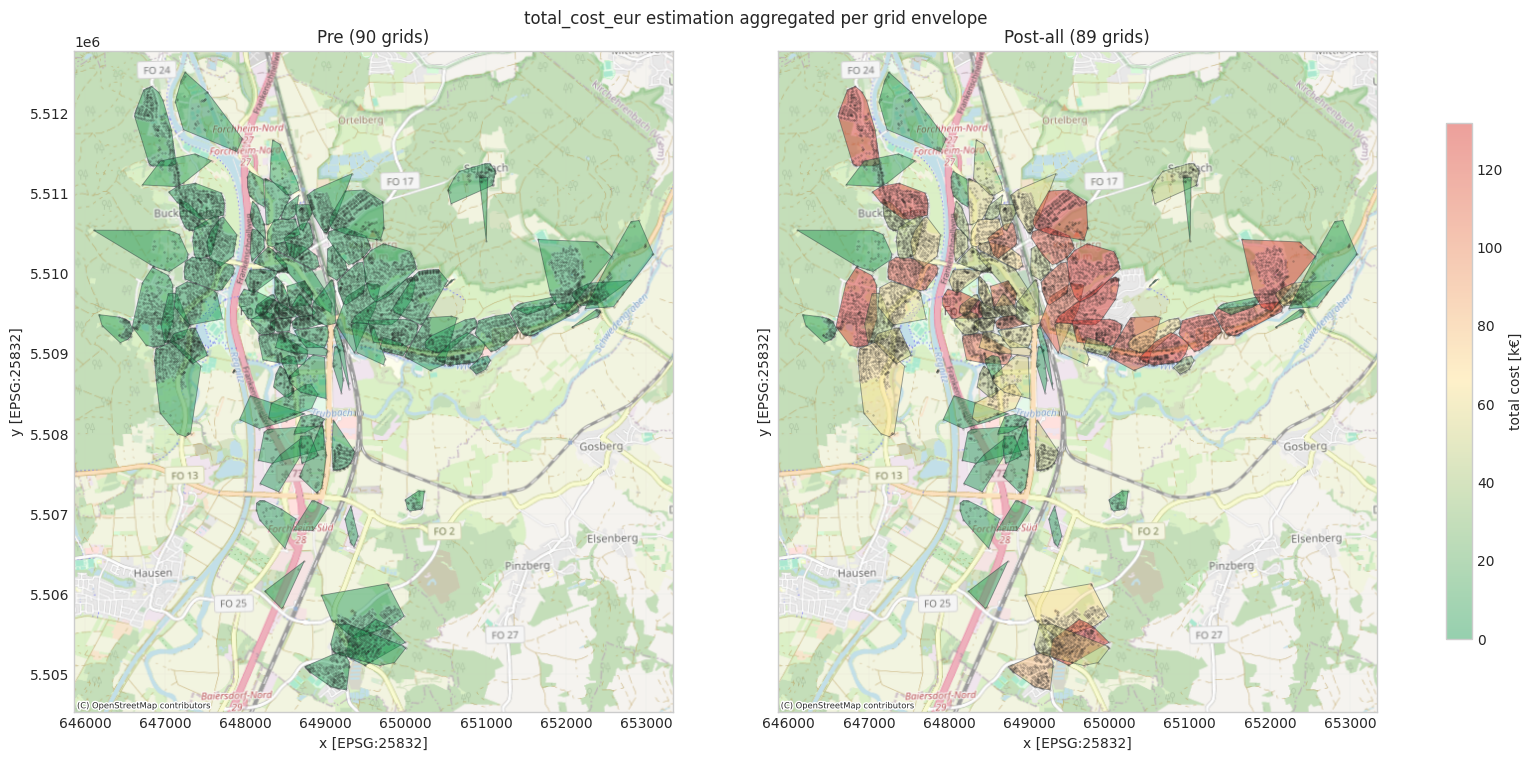

In [7]:
fig, axes, total_envelope_data = geoplotting.plot_synthetic_expansion_envelope_comparison(
    pre_analysis_key=PRE_ANALYSIS_KEY,
    post_analysis_key=POST_ANALYSIS_KEY,
    labels=("Pre", "Post-all"),
    value_column="total_cost_eur",  # transformer_cost_eur, cable_cost_eur, total_cost_eur
    clip_quantile=0.95,
    log_scale=False,
    cmap="cost_green_red",
    output_path=OUTPUT_DIR / "pre_post_total_cost_envelopes.svg",
)
plt.show()


## Summary Tables

Compact table outputs for the materialized expansion analysis and the plotted diagnostics.


In [8]:
expansion_tables["analysis_run"]


,expansion_analysis_run_id,analysis_key,assumption_key,run_name,stage,scenario_id,ags,plz,created_at,note
0,6,full_year_all_tsam_post,de_lv_heuristic_2026,baseline_static_all_summary_powerflow,post,None,9474126,None,2026-07-06 15:12:30.611709+00:00,Materialized from TSAM summary-only full-year ...


In [9]:
expansion_tables["cost_summary"]


,grids_with_line_rows,cable_segments,cable_segments_requiring_expansion,cable_segments_overloaded,cable_cost_eur,transformers,transformers_requiring_expansion,transformers_overloaded,transformer_cost_eur,total_cost_eur
0,88,1231,324,324,976408.821788,89,64,63,4070000.0,5.046409e+06


In [10]:
expansion_tables["grid_cost_summary"].head(10)


,grid_case_id,plz,kcid,bcid,cable_segments,cable_segments_requiring_expansion,cable_cost_eur,max_cable_loading_percent,transformer_rated_power_kva,required_transformer_kva,additional_transformer_kva,transformer_requires_expansion,transformer_cost_eur,transformer_loading_percent,total_cost_eur
0,1894,91301.0,10.0,5.0,26.0,8.0,86305.247503,372.298400,630.0,1800.0,1170.0,True,100000.0,285.128418,186305.247503
1,1842,91301.0,8.0,1.0,28.0,10.0,48231.113884,164.343443,630.0,1100.0,470.0,True,100000.0,170.916805,148231.113884
2,1890,91301.0,10.0,4.0,16.0,7.0,45872.901794,260.123316,630.0,1600.0,970.0,True,100000.0,250.838732,145872.901794
3,1858,91301.0,9.0,5.0,43.0,12.0,44672.616400,196.900455,630.0,1150.0,520.0,True,100000.0,181.390016,144672.616400
4,1838,91301.0,7.0,12.0,30.0,10.0,40892.095325,243.756540,630.0,1700.0,1070.0,True,100000.0,267.329342,140892.095325
5,1918,91301.0,11.0,3.0,17.0,6.0,39754.554207,227.546373,630.0,1250.0,620.0,True,100000.0,193.807639,139754.554207
6,1622,91301.0,1.0,5.0,31.0,13.0,37624.018744,215.598885,630.0,1200.0,570.0,True,100000.0,184.065339,137624.018744
7,1686,91301.0,3.0,3.0,42.0,14.0,37136.148343,265.253633,630.0,1600.0,970.0,True,100000.0,250.757901,137136.148343
8,1898,91301.0,10.0,6.0,21.0,11.0,35339.270089,214.285126,630.0,1450.0,820.0,True,100000.0,230.079063,135339.270089
9,1698,91301.0,4.0,1.0,13.0,7.0,31197.328289,143.644445,630.0,1100.0,470.0,True,100000.0,172.573822,131197.328289


In [11]:
expansion_tables["cable_summary_by_type"]


,visible_std_type,cable_segments,cable_segments_requiring_expansion,length_km,estimated_cost_eur,max_loading_percent
0,NAYY_4_120,1070,223,141.573050,452349.667878,289.793359
1,NAYY_4_240,41,24,11.666817,183778.926725,372.298400
2,NAYY_4_185,51,33,10.820713,157873.250106,264.327624
3,NAYY_4_300,35,20,9.739752,134595.930404,237.387799
4,NAYY_4_150,33,24,5.585471,47811.046675,265.253633
5,NAYY_4_50,1,0,0.017310,0.000000,89.465738


In [12]:
expansion_tables["transformer_summary_by_basis"]


,transformer_cost_basis,transformers,transformers_requiring_expansion,additional_transformer_kva,estimated_cost_eur,max_loading_percent
0,station_rebuild_boundary_case_gt_1000kva,22,22,13990.0,2200000.0,285.128418
1,all_in_replacement_to_1000kva,23,23,7020.0,1104000.0,239.029218
2,all_in_replacement_to_800kva,11,11,1760.0,462000.0,182.995689
3,all_in_replacement_to_630kva,8,8,1300.0,304000.0,143.547878
4,none_existing_capacity_sufficient,25,0,0.0,0.0,97.398599


### Power-Flow Stress Input Coverage


In [13]:
synthetic_summary


,comparison_stage,metric,asset_type,assets,grids
0,Post-all,Cables,cable,44575,89
1,Post-all,Transformer,transformer,445,89
2,Post-all,Voltage,bus,44575,89
3,Pre,Cables,cable,45855,90
4,Pre,Transformer,transformer,450,90
5,Pre,Voltage,bus,45855,90


### Voltage Summary Sample


In [14]:
voltage_summary[["grid", "stage", "n_timesteps", "n_buses", "min_vm_pu", "max_vm_pu"]].head()


NameError: name 'voltage_summary' is not defined

### Envelope Cost Ranking Sample


In [ ]:
total_envelope_data["grid_metrics"].head(5)


,grid_case_id,kcid,bcid,cable_segments,cable_segments_requiring_expansion,cable_cost_eur,max_cable_loading_percent,transformer_requires_expansion,transformer_cost_eur,transformer_loading_percent,additional_transformer_kva,total_cost_eur
0,1894,10,5,26,8,86305.247503,372.298400,True,100000.0,285.128418,1170.0,186305.247503
1,1842,8,1,28,10,48231.113884,164.343443,True,100000.0,170.916805,470.0,148231.113884
2,1890,10,4,16,7,45872.901794,260.123316,True,100000.0,250.838732,970.0,145872.901794
3,1858,9,5,43,12,44672.616400,196.900455,True,100000.0,181.390016,520.0,144672.616400
4,1838,7,12,30,10,40892.095325,243.756540,True,100000.0,267.329342,1070.0,140892.095325
